# Xarray + Cloud OISST (One-Month) Basics & Stats

This notebook demonstrates basic **xarray** operations on a **one-month** subset of a cloud-hosted climate dataset: **NOAA OISST v2.1 daily SST** on AWS Public Datasets (NetCDF files). You'll:
- Discover files for one month on S3 with `fsspec`
- Open them with `xarray.open_mfdataset` (anonymous S3)
- Inspect dataset structure
- Subset in space (and within that month)
- Compute basic stats (mean, std, anomalies relative to the month’s mean)
- Make maps of the month-mean and variability

**Deliverables:** Answer the **🧩 Questions** in the markdown prompts. Fill in the code where indicated by `# TODO`.


In [1]:
import xarray as xr
import fsspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi'] = 120


Matplotlib is building the font cache; this may take a moment.


## 1) Open the cloud dataset (NetCDF on AWS, one month)

We'll access **NOAA OISST v2.1 (daily)** in the NOAA CDR bucket on AWS. Files are arranged by **YYYYMM**.

**🧩 Questions**
1. What engine are we using to read NetCDF files from S3?
2. Why do we need `storage_options={'anon': True}`?
3. Inspect dataset attributes: what are the units and long name of `sst`?


# Answers
1. The engine we are using is h5netcdf.
2. Since the bucket on AWS is open to the public, we need to specify ffspec that credentials are not needed to access the bucket and we can access as an anonymous user, which is done by passing this argument. Otherwise, it would look for credentials and fail. 
3. The unit is Celcius and the long name is 'Daily sea surface temperature'.

In [2]:
yearmonth = "202409"  # TODO: try other months like "201507" or "201909"
prefix = f"noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/{yearmonth}/oisst-avhrr-v02r01.*.nc"

fs = fsspec.filesystem("s3", anon=True)
paths = sorted(fs.glob(prefix))
print(f"Found {len(paths)} files for {yearmonth}. Example:", paths[:2])

urls = [f"s3://{p}" for p in paths]

ds = xr.open_mfdataset(
    urls,
    engine="h5netcdf",
    combine="by_coords",
    decode_times=True,
    mask_and_scale=True,
    backend_kwargs={"storage_options": {"anon": True}},
    chunks={"time": 1}
)

ds


Found 30 files for 202409. Example: ['noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202409/oisst-avhrr-v02r01.20240901.nc', 'noaa-cdr-sea-surface-temp-optimum-interpolation-pds/data/v2.1/avhrr/202409/oisst-avhrr-v02r01.20240902.nc']


<xarray.Dataset> Size: 498MB
Dimensions:  (time: 30, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 240B 2024-09-01T12:00:00 ... 2024-09-30T12...
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    anom     (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    err      (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    Conventions:                CF-1.6, ACDD-1.3
    title:                      NOAA/NCEI 1/4 Degree Daily Optimum Interpolat...
    references:                 Reynolds, et al.(2007) Daily High-Resolution-...
    source:                     ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pathfin...
    id:                         oisst-avhrr-v02r01.20240901.nc
    naming_authority:           gov.noaa.ncei
    ...                         ...
    time_coverage_start:        2024-09-01T00:00:00Z
    time_coverage_end:          2024-09-01T23:59:59Z
    metadata_link:              https://doi.org/10.25921/RE9P-PT57
    ncei_template_version:      NCEI_NetCDF_Grid_Template_v2.0
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    sensor:                     Thermometer, AVHRR

## 2) Explore coordinates & variables

**🧩 Questions**
1. What are the coordinate names for time and space?
2. What is the shape of `sst`?
3. How are missing values represented?


# Answers
1. For time, it is 'time'. For space, we have 'zlev','lat', and 'lon'.
2. (30, 1, 720, 1440)
3. nan

In [3]:
list(ds.data_vars), list(ds.coords)

(['sst', 'anom', 'err', 'ice'], ['time', 'zlev', 'lat', 'lon'])

In [32]:
print(ds)

<xarray.Dataset> Size: 498MB
Dimensions:  (time: 30, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 240B 2024-09-01T12:00:00 ... 2024-09-30T12...
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    anom     (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    err      (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float32 124MB dask.array<chunksize=(1, 1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    Conventions:                CF-1.6, ACDD-1.3
    title:                      NOAA/NCEI 1/4 Degree Daily Optimum Interpolat...
    references:                 Reyn

## 3) Time & space subsetting

We'll select a **regional box** (e.g., Gulf of Mexico) within this month.

**🧩 Questions**
1. What lon/lat bounds did you choose?
2. How many daily steps are present in this month?


# Answers
1. Max lon:-81, Min lon: -90, Max lat: 31, Min lat: 23.5
2. 30

In [23]:
var = "sst"

lon_min, lon_max = -90, -81   # TODO
lat_min, lat_max =  23.5,  31   # TODO

def to_0360(lon):
    lon = np.asarray(lon)
    out = np.mod(lon, 360.0)
    out[out < 0] += 360.0
    return out

lon_min_0360, lon_max_0360 = to_0360([lon_min, lon_max])

dss = ds.sel(
    lon=slice(lon_min_0360, lon_max_0360),
    lat=slice(lat_min, lat_max)
)

dss[var]


<xarray.DataArray 'sst' (time: 30, zlev: 1, lat: 30, lon: 36)> Size: 130kB
dask.array<getitem, shape=(30, 1, 30, 36), dtype=float32, chunksize=(1, 1, 30, 36), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2024-09-01T12:00:00 ... 2024-09-30T12...
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 120B 23.62 23.88 24.12 24.38 ... 30.38 30.62 30.88
  * lon      (lon) float32 144B 270.1 270.4 270.6 270.9 ... 278.4 278.6 278.9
Attributes:
    long_name:  Daily sea surface temperature
    units:      Celsius
    valid_min:  -300
    valid_max:  4500

## 4) Basic statistics

Compute region-wide stats through time and over space **within this month**.

**🧩 Questions**
1. Compute the spatial mean SST time series over your box. What is the monthly average and standard deviation?
2. Compute within-month anomalies (subtract the month-mean). What are the largest positive and negative anomalies?
3. What day had the warmest/coolest region-mean SST?


# Answers 
1. Month mean SST (°C): 29.976041793823242
Month std SST (°C): 0.2499878853559494

2. Max anomaly (°C): 0.2175544798374176
Min anomaly (°C): -0.616217315196991

3. Warmest day: 2024-09-19, 30.1935977935791 °C
Coolest day: 2024-09-28, 29.359825134277344 °C

Month mean SST (°C): 29.976041793823242
Month std SST (°C): 0.2499878853559494


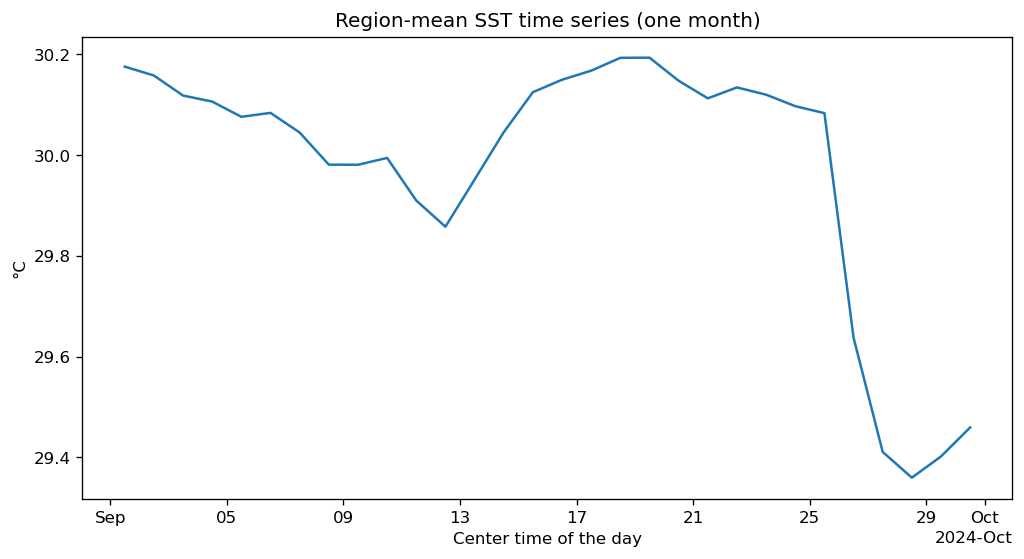

Warmest day: 2024-09-19 30.1935977935791
Coolest day: 2024-09-28 29.359825134277344


/var/folders/wr/1grjyq1x4l38ld6sm3f2fw7m0000gp/T/ipykernel_17298/4235597154.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Warmest day:', pd.to_datetime(ts.time[imax].values).date(), float(ts.isel(time=imax).values))
/var/folders/wr/1grjyq1x4l38ld6sm3f2fw7m0000gp/T/ipykernel_17298/4235597154.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Coolest day:', pd.to_datetime(ts.time[imin].values).date(), float(ts.isel(time=imin).values))


In [24]:
ts = dss[var].mean(dim=['lat','lon'])

ts_mean = ts.mean().compute()
ts_std  = ts.std().compute()
print('Month mean SST (°C):', float(ts_mean.values))
print('Month std SST (°C):', float(ts_std.values))

ts.load().plot()
plt.title('Region-mean SST time series (one month)')
plt.ylabel('°C')
plt.show()

imax = int(ts.argmax('time'))
imin = int(ts.argmin('time'))
print('Warmest day:', pd.to_datetime(ts.time[imax].values).date(), float(ts.isel(time=imax).values))
print('Coolest day:', pd.to_datetime(ts.time[imin].values).date(), float(ts.isel(time=imin).values))


Max anomaly (°C): 0.2175544798374176
Min anomaly (°C): -0.616217315196991


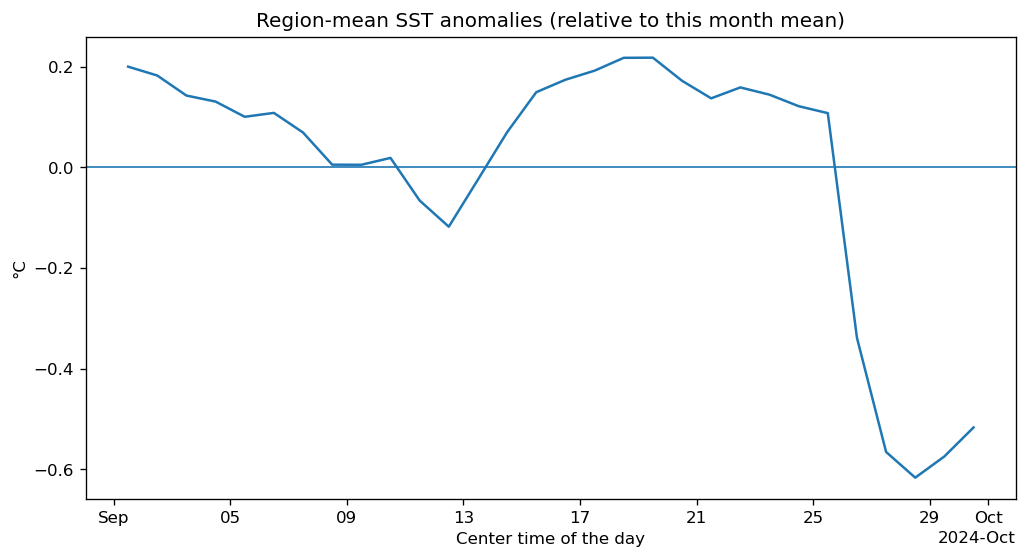

In [25]:
month_mean = dss[var].mean('time')
anom = dss[var] - month_mean

ts_anom = anom.mean(dim=['lat','lon'])
print('Max anomaly (°C):', float(ts_anom.max().compute().values))
print('Min anomaly (°C):', float(ts_anom.min().compute().values))

ts_anom.load().plot()
plt.title('Region-mean SST anomalies (relative to this month mean)')
plt.axhline(0, lw=1)
plt.ylabel('°C')
plt.show()


## 5) Regional maps: month-mean and variability

Make maps of month-mean SST and within-month variability (std and range).

**🧩 Questions**
1. What patterns do you notice?
2. Where is variability strongest?


# Answers
1. The std and range maps are very similar. There also seems to be a tongue of higher variability just west of Florida, associated with the cold wake of Hurricane Helene.

2. Variability is strongest along the northern gulf coast.

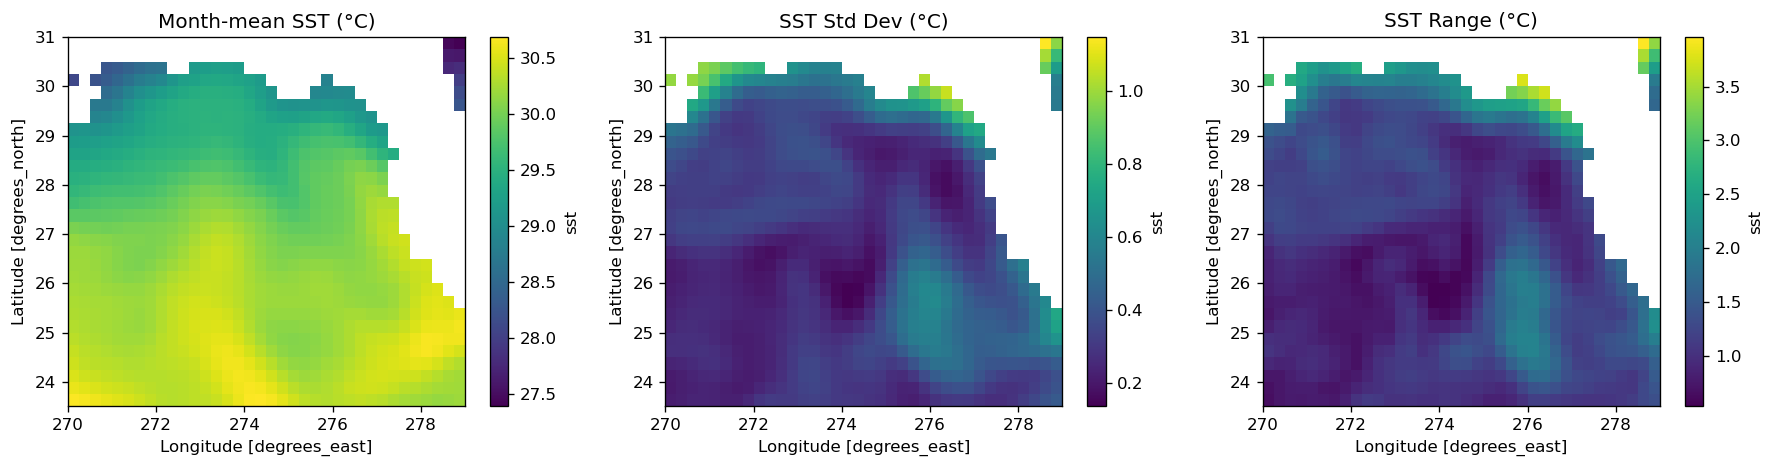

In [22]:
mean_sst = dss[var].mean('time')
std_sst  = dss[var].std('time')
range_sst = dss[var].max('time') - dss[var].min('time')

fig = plt.figure(figsize=(15,4))
ax = plt.subplot(1,3,1); mean_sst.plot(ax=ax); ax.set_title('Month-mean SST (°C)')
ax = plt.subplot(1,3,2); std_sst.plot(ax=ax); ax.set_title('SST Std Dev (°C)')
ax = plt.subplot(1,3,3); range_sst.plot(ax=ax); ax.set_title('SST Range (°C)')
plt.tight_layout(); plt.show()


## 6) Export a small subset for sharing (Check In Problem for Module 2)

Write a NetCDF with your regional mean time series and month-mean/variability maps.  Upload with your committed repository.

In [31]:

ds2 = xr.Dataset(
    {
        "mean_sst_time_series": ts,
        "regional_monthly_sst_mean": mean_sst,
        "regional_monthly_sst_std": std_sst,
        "regional_monthly_sst_range": range_sst
    }
)
print(ds2)

ds2.to_netcdf("monthly_sst_data.nc")

<xarray.Dataset> Size: 14kB
Dimensions:                     (time: 30, zlev: 1, lat: 30, lon: 36)
Coordinates:
  * time                        (time) datetime64[ns] 240B 2024-09-01T12:00:0...
  * zlev                        (zlev) float32 4B 0.0
  * lat                         (lat) float32 120B 23.62 23.88 ... 30.62 30.88
  * lon                         (lon) float32 144B 270.1 270.4 ... 278.6 278.9
Data variables:
    mean_sst_time_series        (time, zlev) float32 120B 30.18 30.16 ... 29.46
    regional_monthly_sst_mean   (zlev, lat, lon) float32 4kB dask.array<chunksize=(1, 30, 36), meta=np.ndarray>
    regional_monthly_sst_std    (zlev, lat, lon) float32 4kB dask.array<chunksize=(1, 30, 36), meta=np.ndarray>
    regional_monthly_sst_range  (zlev, lat, lon) float32 4kB dask.array<chunksize=(1, 30, 36), meta=np.ndarray>
